## CMPINF 2100 Final Project

### Models: Fitting & Interpretation 
*Note: BEFORE FITTING THE MODELS. If your EDA revealed that some continuous variables are not “Gaussian-like”, apply the natural log or square root transformation to those variables before modeling.  If your EDA revealed that the continuous variables have vastly different scales, you MUST standardize the variables before modeling.*
* You must fit multiple models to predict the response of interest.
* If you are working on a classification problem, you must use logistic regression models. You must use statsmodels to fit these models.
* You will consider multiple formulations (FEATURES included in the model) and study the coefficients and their confidence intervals to interpret feature importance and relationships to the response.
* Formulations you must consider:
  * No INPUTS! Fit an INTERCEPT-ONLY or CONSTANT AVERAGE model.
  * Categorical inputs with additive features.
  * Continuous inputs with linear additive features.
  * All inputs (continuous and categorical) with linear additive features.
  * Continuous inputs with linear main effect and pair-wise interactions.
  * Interact the categorical inputs with the continuous inputs. This model must include the linear main effects as well (the formula interface helps with the interactions).
* You MUST also try 2 additional formulations. The additional formulations are up to you, but base you choices on your EDA. So what could you try? Here are several examples:
  * If you noticed a potential non-linear relationship between the output and an INPUT you should include polynomial features in the model. You may want to try interacting categorical inputs with linear (main effect) and polynomial features derived from the continuous inputs. This checks if the non-linear relationship changes across categories.
  * If you noticed the output has cyclical behavior or a repeating pattern with respect to an input then you could apply the SIN() function to inputs. You should standardize the inputs BEFORE applying SIN(). Interacting the SIN() function with categorical inputs allows you to check if the repeating pattern changes across categories.
  * You will fit a total of 8 models. The Spotify Songs application has a single main output. As stated in the project feedback, you can treat this as a regression task after applying an appropriate transformation. Alternatively, you can convert the problem to a classification task. You may decide which approach you want to work on.
* For each model that you fit you must answer the following questions associated with the regression coefficients:
  * How many coefficients were estimated?
  * How many coefficients (and thus features) are STATISTICALLY SIGNIFICANT using commonly accepted thresholds?
  * WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and what are the coefficients POSITIVE or NEGATIVE for those features?
  * Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?
* For each model that you fit you must show the performance on the training set. What you show depends on whether you are working on a REGRESSION or CLASSIFICATION task.
  * CLASSIFICATION
    * For each model show the CONFUSION MATRIX on the training set assuming a 0.5 threshold; the Accuracy, Sensitivity, Specificity, and FPR on the training set assuming a 0.5 threshold; the ROC curve on the training set; and the Area Under the ROC curve (ROC AUC) value.
    * Which model has the best performance on the training set? Is the best model different when considering Accuracy vs ROC AUC? Is the best model better than the INTERCEPT-ONLY model? How many coefficients are associated with the BEST model?

## Import Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
import statsmodels.formula.api as smf

In [3]:
from sklearn.metrics import confusion_matrix

In [4]:
from sklearn.metrics import roc_curve

In [5]:
from sklearn.metrics import roc_auc_score

## Read Data

In [6]:
dfa = pd.read_csv('spotify_data_standard_clean.csv')

In [7]:
dfa.columns

Index(['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
       'playlist_genre', 'key', 'mode', 'release_month', 'binary_outcome',
       'bin_year'],
      dtype='object')

### Select Data

In [8]:
## modify release_month, playlist_genre, key, bin_year, and mode to categoricals

dfa['release_month'] = dfa.release_month.astype('category')
dfa['playlist_genre'] = dfa.playlist_genre.astype('category')
dfa['mode'] = dfa['mode'].astype('category')
dfa['key'] = dfa.key.astype('category')
dfa['bin_year'] = dfa.bin_year.astype('category')

In [9]:
dfa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   danceability      28356 non-null  float64 
 1   energy            28356 non-null  float64 
 2   loudness          28356 non-null  float64 
 3   speechiness       28356 non-null  float64 
 4   acousticness      28356 non-null  float64 
 5   instrumentalness  28356 non-null  float64 
 6   liveness          28356 non-null  float64 
 7   valence           28356 non-null  float64 
 8   tempo             28356 non-null  float64 
 9   duration_ms       28356 non-null  float64 
 10  playlist_genre    28356 non-null  category
 11  key               28356 non-null  category
 12  mode              28356 non-null  category
 13  release_month     28356 non-null  category
 14  binary_outcome    28356 non-null  int64   
 15  bin_year          28356 non-null  category
dtypes: category(5), float6

#### Define a list of formulas

In [10]:
formula_list = ['binary_outcome ~ 1',
         'binary_outcome ~ bin_year + playlist_genre + key + mode + release_month',
         'binary_outcome ~ danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms',
         'binary_outcome ~ bin_year + playlist_genre + key + mode + release_month + danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms',
         'binary_outcome ~ (danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms) ** 2',
          'binary_outcome ~ (bin_year + playlist_genre + key + mode + release_month) * (danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms)',
          'binary_outcome ~ (bin_year + playlist_genre + key + mode + release_month) * ((danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms)**2) + np.power(danceability, 2) + np.power(energy, 2) + np.power(loudness, 2) + np.power(speechiness, 2) + np.power(acousticness, 2) + np.power(instrumentalness, 2) + np.power(liveness, 2) + np.power(valence, 2) + np.power(tempo, 2) + np.power(duration_ms, 2)',
         'binary_outcome ~ (bin_year + playlist_genre + key + mode + release_month) * (np.power(danceability, 2) + np.power(energy, 2) + np.power(loudness, 2) + np.power(speechiness, 2) + np.power(acousticness, 2) + np.power(instrumentalness, 2) + np.power(liveness, 2) + np.power(valence, 2) + np.power(tempo, 2) + np.power(duration_ms, 2))']

In [11]:
len(formula_list)

8

Prior to fitting the models, I'll define a couple of functions to help streamline operations

In [12]:
def significant_coefs(mod):
    ## statistically significant features
    significant = mod.pvalues[mod.pvalues < 0.05]
    
    ## get their coefficients
    significant_coefs = mod.params[significant.index]
    
    ## see if they are positive or negative
    result = pd.DataFrame({'coef_value': significant_coefs,
    'sign': ['positive' if x > 0 else 'negative' for x in significant_coefs]})

    return result

In [13]:
def print_coef_summaries(mod):
    print('Coefficients Estimated:', len(mod.params))
    print('Number of Statistically Significant Coefficients:', (mod.pvalues < 0.05).sum())

In [14]:
def two_most_sig_coef(mod):
    ## create a dataframe of the pvalues and if they are significant
    mod_pvalue_df = pd.merge(pd.DataFrame(mod.pvalues).reset_index().rename(columns={'index':'feature', 0:'pvalue'}),
         pd.DataFrame(mod.pvalues < 0.05).reset_index().rename(columns={'index':'feature', 0:'significant'}),
         how='left', on='feature')

    ## add positive/negative column
    mod_pvalue_df['sign'] = np.where(mod_pvalue_df.pvalue > 0, 'pos', 'neg')

    ## add absolute value column
    mod_pvalue_df['absolute_value'] = np.abs(mod_pvalue_df.pvalue).round(8)

    ## return the two highest absolute pvalues
    return mod_pvalue_df.loc[mod_pvalue_df.significant == True, :].sort_values(by='absolute_value', ascending=False)[:2]

## Model 0

In [15]:
fit_0 = smf.logit(formula = formula_list[0], data = dfa).fit()

Optimization terminated successfully.
         Current function value: 0.691732
         Iterations 3


In [16]:
significant_coefs(fit_0)

,coef_value,sign
Intercept,0.106462,positive


In [17]:
print_coef_summaries(fit_0)

Coefficients Estimated: 1
Number of Statistically Significant Coefficients: 1


In [18]:
two_most_sig_coef(fit_0)

,feature,pvalue,significant,sign,absolute_value
0,Intercept,3.521304e-19,True,pos,0.0


Since this is an intercept only model, the one coefficient, the intercept, is positive and significant.

## Model 1

In [19]:
fit_1 = smf.logit(formula = formula_list[1], data = dfa).fit()

Optimization terminated successfully.
         Current function value: 0.668754
         Iterations 4


In [20]:
significant_coefs(fit_1)

,coef_value,sign
Intercept,-1.037242,negative
bin_year[T.recent],0.242916,positive
playlist_genre[T.latin],1.033908,positive
playlist_genre[T.pop],1.170569,positive
playlist_genre[T.r&b],0.592097,positive
playlist_genre[T.rap],1.131165,positive
playlist_genre[T.rock],1.042513,positive
key[T.2],-0.135018,negative
key[T.8],0.139908,positive
release_month[T.5],0.196846,positive


In [21]:
print_coef_summaries(fit_1)

Coefficients Estimated: 30
Number of Statistically Significant Coefficients: 17


In [22]:
two_most_sig_coef(fit_1)

,feature,pvalue,significant,sign,absolute_value
14,key[T.8],0.017812,True,pos,0.017812
8,key[T.2],0.015222,True,pos,0.015222


## Model 2

In [23]:
fit_2 = smf.logit(formula = formula_list[2], data = dfa).fit()

Optimization terminated successfully.
         Current function value: 0.671088
         Iterations 5


In [24]:
significant_coefs(fit_2)

,coef_value,sign
Intercept,0.106449,positive
energy,-0.323265,negative
loudness,0.251933,positive
speechiness,-0.032061,negative
acousticness,0.074589,positive
instrumentalness,-0.150256,negative
liveness,-0.046348,negative
valence,0.060084,positive
tempo,0.040515,positive
duration_ms,-0.208486,negative


In [25]:
print_coef_summaries(fit_2)

Coefficients Estimated: 11
Number of Statistically Significant Coefficients: 10


In [26]:
two_most_sig_coef(fit_2)

,feature,pvalue,significant,sign,absolute_value
4,speechiness,0.010383,True,pos,0.010383
9,tempo,0.001239,True,pos,0.001239


## Model 3

In [27]:
fit_3 = smf.logit(formula = formula_list[3], data = dfa).fit()

Optimization terminated successfully.
         Current function value: 0.655160
         Iterations 5


In [28]:
significant_coefs(fit_3)

,coef_value,sign
Intercept,-0.714244,negative
playlist_genre[T.latin],0.794489,positive
playlist_genre[T.pop],0.963800,positive
playlist_genre[T.r&b],0.312215,positive
playlist_genre[T.rap],0.882270,positive
playlist_genre[T.rock],1.016660,positive
key[T.2],-0.113222,negative
key[T.8],0.142548,positive
release_month[T.5],0.185718,positive
release_month[T.6],0.247353,positive


In [29]:
print_coef_summaries(fit_3)

Coefficients Estimated: 40
Number of Statistically Significant Coefficients: 25


In [30]:
two_most_sig_coef(fit_3)

,feature,pvalue,significant,sign,absolute_value
8,key[T.2],0.044662,True,pos,0.044662
36,liveness,0.019025,True,pos,0.019025


## Model 4

In [31]:
fit_4 = smf.logit(formula = formula_list[4], data = dfa).fit()

Optimization terminated successfully.
         Current function value: 0.664365
         Iterations 5


In [32]:
significant_coefs(fit_4)

,coef_value,sign
Intercept,0.090007,positive
energy,-0.309834,negative
loudness,0.270649,positive
speechiness,-0.038559,negative
acousticness,0.083617,positive
instrumentalness,-0.157435,negative
liveness,-0.044620,negative
valence,0.038700,positive
duration_ms,-0.201780,negative
danceability:energy,-0.077120,negative


In [33]:
print_coef_summaries(fit_4)

Coefficients Estimated: 56
Number of Statistically Significant Coefficients: 24


In [34]:
two_most_sig_coef(fit_4)

,feature,pvalue,significant,sign,absolute_value
17,danceability:valence,0.048635,True,pos,0.048635
16,danceability:liveness,0.042159,True,pos,0.042159


## Model 5

In [35]:
fit_5 = smf.logit(formula = formula_list[5], data = dfa).fit()

Optimization terminated successfully.
         Current function value: 0.640975
         Iterations 6


In [36]:
significant_coefs(fit_5)

,coef_value,sign
Intercept,-0.661322,negative
playlist_genre[T.latin],0.684828,positive
playlist_genre[T.pop],0.930023,positive
playlist_genre[T.r&b],0.181395,positive
playlist_genre[T.rap],0.804378,positive
...,...,...
key[T.9]:duration_ms,-0.281280,negative
key[T.10]:duration_ms,-0.145334,negative
key[T.11]:duration_ms,-0.283643,negative
release_month[T.2]:duration_ms,0.148798,positive


In [37]:
print_coef_summaries(fit_5)

Coefficients Estimated: 330
Number of Statistically Significant Coefficients: 73


In [38]:
two_most_sig_coef(fit_5)

,feature,pvalue,significant,sign,absolute_value
286,key[T.10]:tempo,0.048862,True,pos,0.048862
146,release_month[T.9]:speechiness,0.048233,True,pos,0.048233


## Model 6

In [39]:
fit_6 = smf.logit(formula = formula_list[6], data = dfa).fit()

Optimization terminated successfully.
         Current function value: 0.604431
         Iterations 7


In [40]:
significant_coefs(fit_6)

,coef_value,sign
Intercept,-0.752711,negative
playlist_genre[T.latin],0.688544,positive
playlist_genre[T.pop],0.964528,positive
playlist_genre[T.rap],0.928887,positive
playlist_genre[T.rock],0.977639,positive
...,...,...
"np.power(danceability, 2)",0.035774,positive
"np.power(energy, 2)",-0.097102,negative
"np.power(acousticness, 2)",-0.056098,negative
"np.power(instrumentalness, 2)",0.048654,positive


In [41]:
print_coef_summaries(fit_6)

Coefficients Estimated: 1690
Number of Statistically Significant Coefficients: 192


In [42]:
two_most_sig_coef(fit_6)

,feature,pvalue,significant,sign,absolute_value
112,release_month[T.5]:loudness,0.049895,True,pos,0.049895
92,playlist_genre[T.latin]:loudness,0.049539,True,pos,0.049539


## Model 7

In [43]:
fit_7 = smf.logit(formula = formula_list[7], data = dfa).fit()

Optimization terminated successfully.
         Current function value: 0.654088
         Iterations 6


In [44]:
significant_coefs(fit_7)

,coef_value,sign
Intercept,-0.873138,negative
bin_year[T.recent],0.223834,positive
playlist_genre[T.latin],0.754850,positive
playlist_genre[T.pop],1.050990,positive
playlist_genre[T.r&b],0.311828,positive
playlist_genre[T.rap],0.881489,positive
playlist_genre[T.rock],0.924749,positive
release_month[T.5],0.312056,positive
release_month[T.6],0.216856,positive
release_month[T.8],0.206380,positive


In [45]:
print_coef_summaries(fit_7)

Coefficients Estimated: 330
Number of Statistically Significant Coefficients: 55


In [46]:
two_most_sig_coef(fit_7)

,feature,pvalue,significant,sign,absolute_value
205,"release_month[T.8]:np.power(instrumentalness, 2)",0.047966,True,pos,0.047966
27,release_month[T.10],0.047920,True,pos,0.047920


## Confusion Matricies

For each model show the CONFUSION MATRIX on the training set assuming a 0.5 threshold; the Accuracy, Sensitivity, Specificity, and FPR on the training set assuming a 0.5 threshold

In [47]:
## define a function to create the confusion matrix for one model and store the result in a dataframe
def show_confusion(mod_name, a_formula, train_data, threshold):
    a_mod = smf.logit(formula=a_formula, data=train_data).fit()
    train_copy = train_data.copy()
    train_copy['pred_probability'] = a_mod.predict(train_data)
    train_copy['pred_class'] = np.where(train_copy.pred_probability > threshold, 1, 0)
    TN, FP, FN, TP = confusion_matrix(train_copy.binary_outcome.to_numpy(), train_copy.pred_class.to_numpy()).ravel()
    res_dict = {'True Negative':TN,
               'False Positive':FP,
               'False Negative':FN,
               'True Positive':TP}
    return pd.DataFrame(res_dict, index=[0])

In [48]:
## check to see if it works on one model
show_confusion(0, formula_list[0], dfa, 0.5)

Optimization terminated successfully.
         Current function value: 0.691732
         Iterations 3


,True Negative,False Positive,False Negative,True Positive
0,0,13424,0,14932


In [49]:
## initiate a list and iterate over the formulas
confusion_list = []

for m in range(len(formula_list)):
    confusion_list.append(show_confusion( m, formula_list[m], train_data=dfa, threshold=0.5))

## combine the resulting dataframes into one
confusion_df = pd.concat(confusion_list, ignore_index=True)

Optimization terminated successfully.
         Current function value: 0.691732
         Iterations 3
Optimization terminated successfully.
         Current function value: 0.668754
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.671088
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.655160
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664365
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.640975
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.604431
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.654088
         Iterations 6


In [50]:
## rename the index column for easy viewing
confusion_df.reset_index().rename(columns={'index':'model_name'})

,model_name,True Negative,False Positive,False Negative,True Positive
0,0,0,13424,0,14932
1,1,5776,7648,3840,11092
2,2,5699,7725,3976,10956
3,3,6586,6838,4121,10811
4,4,5864,7560,3943,10989
5,5,7141,6283,4102,10830
6,6,7843,5581,3946,10986
7,7,6505,6919,3960,10972


## Fitting and Assessing Performance

In [51]:
## function copied from 'week_12_classification_multiple_models.ipynb'

def fit_and_assess_logistic(mod_name, a_formula, train_data, threshold):
    a_mod = smf.logit(formula=a_formula, data=train_data).fit()
    train_copy = train_data.copy()
    train_copy['pred_probability'] = a_mod.predict(train_data)
    train_copy['pred_class'] = np.where(train_copy.pred_probability > threshold, 1, 0)
    TN, FP, FN, TP = confusion_matrix(train_copy.binary_outcome.to_numpy(), train_copy.pred_class.to_numpy()).ravel()
    Accuracy = (TN + TP) / (TN + TP + FP + FN)
    Sensitivity = (TP) / (TP + FN)
    Specificity = (TN) / (TN + FP)
    FPR = 1 - Specificity
    ROC_AUC = roc_auc_score(train_copy.binary_outcome.to_numpy(), train_copy.pred_probability.to_numpy())
    res_dict = {'model_name': mod_name,
               'model formula' : a_formula,
               'num_coefs': len(a_mod.params),
               'threshold': threshold,
               'Accuracy': Accuracy,
               'Sensitivity': Sensitivity,
               'Specificity': Specificity,
               'FPR': FPR,
               'ROC_AUC': ROC_AUC}
    return pd.DataFrame(res_dict, index=[0])

In [52]:
## test on one model

fit_and_assess_logistic(2, formula_list[2], dfa, 0.5)

Optimization terminated successfully.
         Current function value: 0.671088
         Iterations 5


,model_name,model formula,num_coefs,threshold,Accuracy,Sensitivity,Specificity,FPR,ROC_AUC
0,2,binary_outcome ~ danceability + energy + loudn...,11,0.5,0.587354,0.733726,0.424538,0.575462,0.614421


In [54]:
## initiate an empty list
results_list = []

## iterate and store results
for m in range(len(formula_list)):
    results_list.append( fit_and_assess_logistic( m, formula_list[m], train_data=dfa, threshold=0.5))

## combine results into one dataframe
results_df = pd.concat(results_list, ignore_index=True)

## modify model_name into a category for better viz
results_df['model_name'] = results_df.model_name.astype('category')

results_df

Optimization terminated successfully.
         Current function value: 0.691732
         Iterations 3
Optimization terminated successfully.
         Current function value: 0.668754
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.671088
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.655160
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664365
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.640975
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.604431
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.654088
         Iterations 6


,model_name,model formula,num_coefs,threshold,Accuracy,Sensitivity,Specificity,FPR,ROC_AUC
0,0,binary_outcome ~ 1,1,0.5,0.526590,1.000000,0.000000,1.000000,0.500000
1,1,binary_outcome ~ bin_year + playlist_genre + k...,30,0.5,0.594865,0.742834,0.430274,0.569726,0.618489
2,2,binary_outcome ~ danceability + energy + loudn...,11,0.5,0.587354,0.733726,0.424538,0.575462,0.614421
3,3,binary_outcome ~ bin_year + playlist_genre + k...,40,0.5,0.613521,0.724016,0.490614,0.509386,0.651638
4,4,binary_outcome ~ (danceability + energy + loud...,56,0.5,0.594336,0.735936,0.436830,0.563170,0.628555
5,5,binary_outcome ~ (bin_year + playlist_genre + ...,330,0.5,0.633764,0.725288,0.531958,0.468042,0.679199
6,6,binary_outcome ~ (bin_year + playlist_genre + ...,1690,0.5,0.664022,0.735735,0.584252,0.415748,0.727187
7,7,binary_outcome ~ (bin_year + playlist_genre + ...,330,0.5,0.616342,0.734798,0.484580,0.515420,0.651009


/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


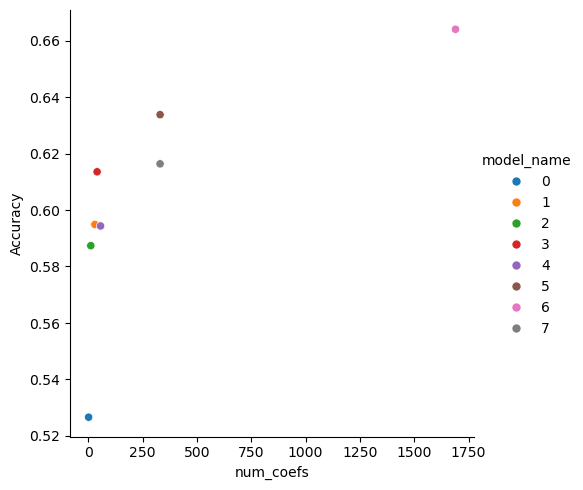

In [55]:
sns.relplot(data=results_df, x='num_coefs', y='Accuracy', kind='scatter',
           hue='model_name')

plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


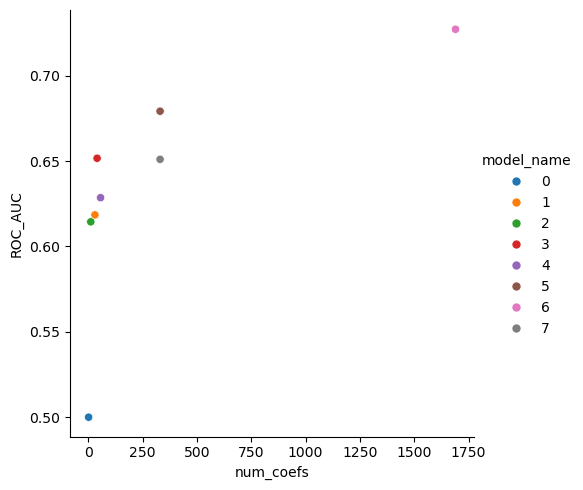

In [56]:
sns.relplot(data=results_df, x='num_coefs', y='ROC_AUC', kind='scatter',
           hue='model_name')

plt.show()

In [57]:
## function copied from 'week_12_classification_multiple_models.ipynb'

def fit_logistic_make_roc(mod_name, a_formula, train_data):
    a_mod = smf.logit(formula = a_formula, data = train_data).fit()
    train_copy = train_data.copy()
    train_copy['pred_probability'] = a_mod.predict(train_data)
    fpr, tpr, threshold = roc_curve(train_data.binary_outcome.to_numpy(), train_copy.pred_probability.to_numpy())
    res_df = pd.DataFrame({'tpr':tpr,
                          'fpr':fpr,
                          'threshold':threshold})
    res_df['model_name'] = mod_name
    res_df['model_formula'] = a_formula
    return res_df

In [58]:
## follow same procedure as above for iteration and storage
roc_list = []

for m in range(len(formula_list)):
    roc_list.append( fit_logistic_make_roc( mod_name=m, a_formula=formula_list[m], train_data=dfa))

roc_df = pd.concat(roc_list, ignore_index=True)

roc_df['model_name'] = roc_df.model_name.astype('category')

roc_df

Optimization terminated successfully.
         Current function value: 0.691732
         Iterations 3
Optimization terminated successfully.
         Current function value: 0.668754
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.671088
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.655160
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664365
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.640975
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.604431
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.654088
         Iterations 6


,tpr,fpr,threshold,model_name,model_formula
0,0.000000,0.000000,inf,0,binary_outcome ~ 1
1,1.000000,1.000000,0.526590,0,binary_outcome ~ 1
2,0.000000,0.000000,inf,1,binary_outcome ~ bin_year + playlist_genre + k...
3,0.001406,0.000521,0.691689,1,binary_outcome ~ bin_year + playlist_genre + k...
4,0.002679,0.001192,0.690155,1,binary_outcome ~ bin_year + playlist_genre + k...
...,...,...,...,...,...
81846,0.999866,0.999479,0.027629,7,binary_outcome ~ (bin_year + playlist_genre + ...
81847,0.999933,0.999479,0.023893,7,binary_outcome ~ (bin_year + playlist_genre + ...
81848,0.999933,0.999851,0.011757,7,binary_outcome ~ (bin_year + playlist_genre + ...
81849,1.000000,0.999851,0.011015,7,binary_outcome ~ (bin_year + playlist_genre + ...


/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


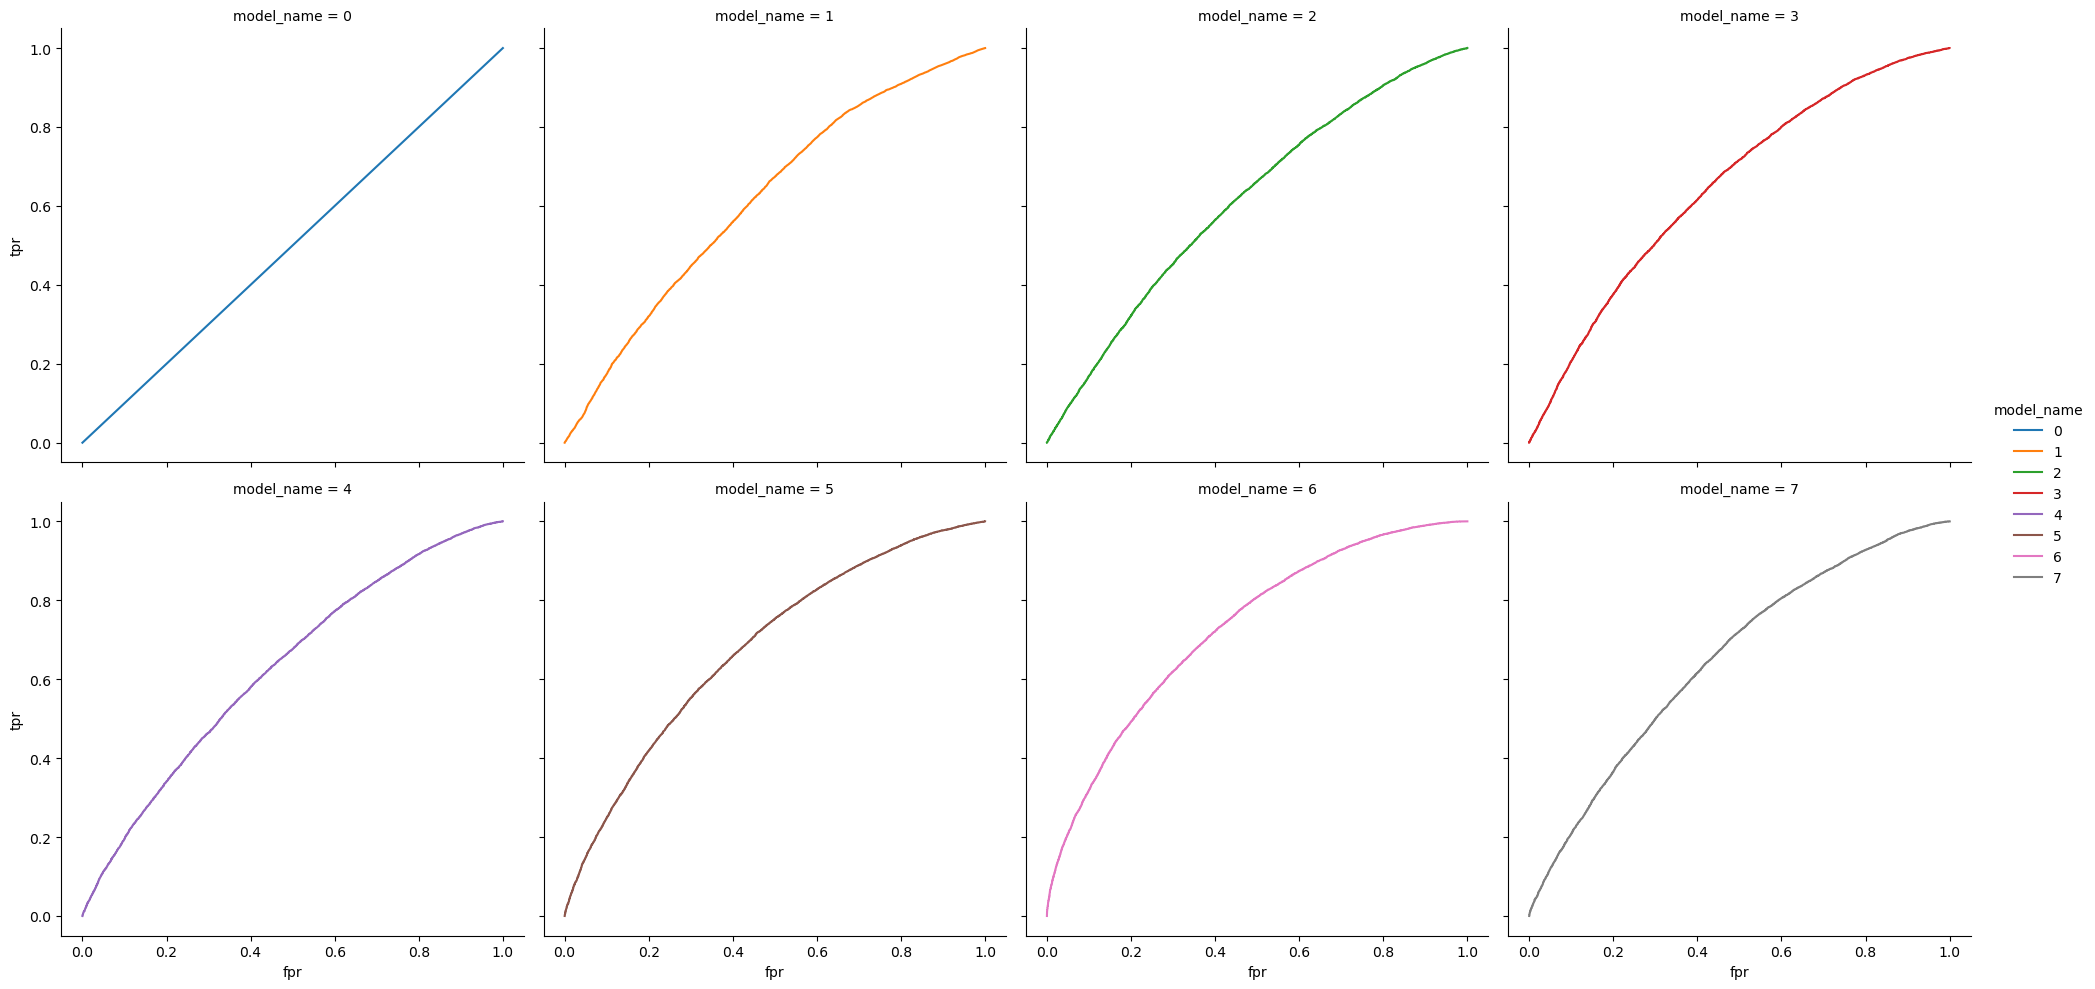

In [59]:
sns.relplot(data=roc_df, x='fpr', y='tpr', hue='model_name',
           kind='line', estimator=None, units='model_name',
           col='model_name', col_wrap=4)

plt.show()

**Which model has the best performance on the training set? Is the best model different when considering Accuracy vs ROC AUC? Is the best model better than the INTERCEPT-ONLY model? How many coefficients are associated with the BEST model?**

Model 6 has the best performance on the training set by Accuracy and ROC AUC. It did perform better than intercept only. Model 6 has 1690 coefficients estimated. 